In [19]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import mnist
plt.style.use('dark_background')
%matplotlib inline

In [20]:
np.set_printoptions(precision=2)


In [21]:
import tensorflow as tf

In [22]:
## Load MNIST data
(X_train, _), (X_test, _) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1]*X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1]*X_test.shape[2])

In [23]:
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


In [24]:
num_features = X_train.shape[1]
num_samples = X_train.shape[0]


# Normalize the samples (images)
xmax = np.amax(X_train)
xmin = np.amin(X_train)
X_train = (X_train - xmin) / (xmax - xmin) # all train features turn into a number between 0 and 1
X_test = (X_test - xmin)/(xmax - xmin)

print('MNIST set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))

MNIST set
---------------------
Number of training samples = 60000
Number of features = 784


In [25]:
#Parameters for the autoencoder
batch_size = 256
max_epochs = 50
learning_rate = 1e-3
latent_dim = 128
hidden_dim = 256
original_dim = X_train.shape[1]

In [26]:
type(X_train)

numpy.ndarray

In [27]:
#Covert numpy to tf.data.Dataset
training_dataset = tf.data.Dataset.from_tensor_slices(X_train).batch(batch_size)

In [28]:
#Encoder
class Encoder(tf.keras.layers.Layer):
    #Define input independent model information
    def __init__(self, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.encoder_layer1 = tf.keras.layers.Dense(units=hidden_dim, activation=tf.nn.relu) #hidden layer
        self.encoder_layer2 = tf.keras.layers.Dense(units=latent_dim, activation=tf.nn.relu) #latent layer

    #Method for forward propagation
    def call(self, input_features):
        a = None
        a = self.encoder_layer1(input_features)
        a = self.encoder_layer2(a)
        return a

In [29]:
#Decoder
class Decoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim, hidden_dim, original_dim):
        super(Decoder, self).__init__()
        self.decoder_layer1 = tf.keras.layers.Dense(units=hidden_dim, activation=tf.nn.relu)
        self.decoder_layer2 = tf.keras.layers.Dense(units=original_dim, activation=tf.nn.relu)

    def call(self, encoded_feature):
        a = self.decoder_layer1(encoded_feature)
        a = self.decoder_layer2(a)
        return a


In [30]:
#Autoencoder
class Autoencoder(tf.keras.Model):
    def __init__(self, latent_dim, hidden_dim, original_dim):
        super(Autoencoder, self).__init__()
        self.loss = []
        self.encoder = Encoder(hidden_dim = hidden_dim, latent_dim = latent_dim)
        self.decoder = Decoder(latent_dim = latent_dim, hidden_dim = hidden_dim, original_dim = original_dim)

    def call(self, input_features):
        encoded_features = self.encoder(input_features)
        reconstructed_features = self.decoder(encoded_features)
        return reconstructed_features

In [31]:
#Build the model
autoencoder = Autoencoder(latent_dim = latent_dim, hidden_dim = hidden_dim, original_dim = original_dim)    

In [32]:
opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)

In [37]:
#Custom training
def loss(true, pred):
    true = tf.cast(true, tf.float32)
    pred = tf.cast(pred, tf.float32)    
    return tf.reduce_mean(tf.square(tf.subtract(true, pred)))

In [38]:
#Custom training - compute gradient of loss and update weights
def train(loss, model, opt, original_features):
    with tf.GradientTape() as g:
        pred = model(original_features)
        reconstruction_error = loss(original_features, pred)
    gradients = g.gradient(reconstruction_error, model.trainable_variables)
    gradients_variables = zip(gradients, model.trainable_variables)
    opt.apply_gradients(gradients_variables)

    return reconstruction_error

In [39]:
#Train network
def train_loop(model, opt, loss, dataset, epochs = 10):
    for epoch in range(epochs):
        epoch_loss = 0
        for step, batch_features in enumerate(dataset):
            loss_batch =  train(loss, model, opt, batch_features)
            epoch_loss += loss_batch
        epoch_loss /= batch_size
        model.loss.append(epoch_loss)
        print(f'Epoch {epoch}, loss = {epoch_loss.numpy()}')


In [40]:
train_loop(autoencoder, opt, loss, training_dataset, epochs = max_epochs)

Epoch 0, loss = 0.024498621001839638
Epoch 1, loss = 0.010950573720037937
Epoch 2, loss = 0.009268728084862232
Epoch 3, loss = 0.008449461311101913
Epoch 4, loss = 0.00796773936599493
Epoch 5, loss = 0.007665268145501614
Epoch 6, loss = 0.0074097407050430775
Epoch 7, loss = 0.007249537855386734
Epoch 8, loss = 0.007079172879457474
Epoch 9, loss = 0.0069650923833251
Epoch 10, loss = 0.006856056395918131
Epoch 11, loss = 0.006783363409340382
Epoch 12, loss = 0.006732666864991188
Epoch 13, loss = 0.006639237981289625
Epoch 14, loss = 0.0065619684755802155
Epoch 15, loss = 0.006557956803590059
Epoch 16, loss = 0.006469879299402237
Epoch 17, loss = 0.0064603728242218494
Epoch 18, loss = 0.0064073847606778145
Epoch 19, loss = 0.006376054137945175
Epoch 20, loss = 0.006383830681443214
Epoch 21, loss = 0.006321472581475973
Epoch 22, loss = 0.006333165802061558
Epoch 23, loss = 0.006268572993576527
Epoch 24, loss = 0.006281927693635225
Epoch 25, loss = 0.006247823126614094
Epoch 26, loss = 0.00

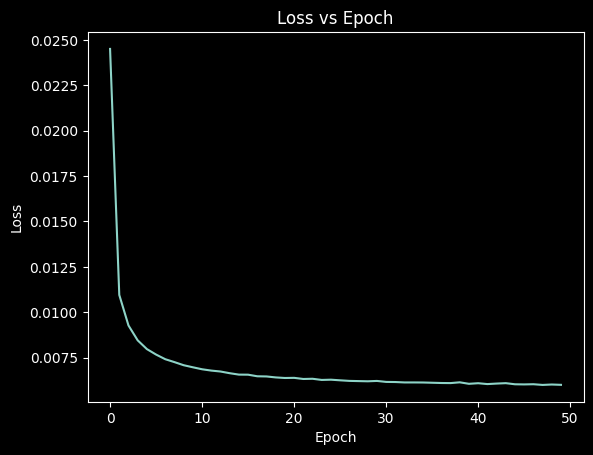

In [41]:
plt.plot(autoencoder.loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.show()


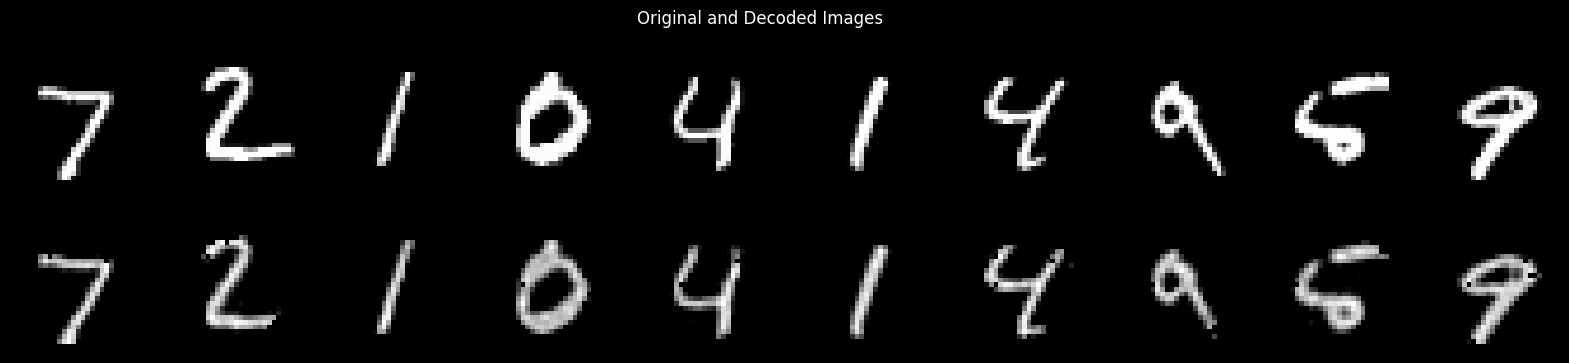

In [42]:
# Plot the original and decoded images
original_images = X_test[:10]
decoded_images = autoencoder(original_images)

# Plot the original and decoded images
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(original_images[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(decoded_images[i].numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

plt.suptitle('Original and Decoded Images')
plt.show()
